# Bank Churn Prediction

## Background

Businesses, such as banks that provide services, face the challenge of "churn," which refers to customers leaving and switching to another service provider. It is crucial to identify the factors that influence a customer's decision to stay or leave. By understanding these key aspects, management can focus on improving service quality while prioritizing efforts to retain customers effectively.

---

## Main Objective

The goal is to build a model that can predict whether a given bank customer will leave the service within the next six months.

---

## Procedures

1. **Overview of the Data**  
   Understand the dataset structure and key variables.

2. **Initial Data Preprocessing**  
   Prepare the dataset for analysis, addressing issues like missing data, inconsistent formatting, and encoding.

3. **Exploratory Data Analysis (EDA)**  
   Analyze and visualize data to uncover patterns and relationships.

4. **Additional Data Preprocessing**  
   Refine the dataset further, applying feature scaling, transformations, and handling categorical variables.

5. **Model Building**  
   Construct a neural network classifier tailored to the problem.

6. **Model Performance Improvement**  
   Optimize the model using techniques such as hyperparameter tuning or regularization.

7. **Model Performance Evaluation**  
   Assess the model using metrics like accuracy, precision, recall, and AUC-ROC to ensure reliability.

8. **Actionable Insights & Recommendations**  
   Derive insights from the model and suggest strategies for customer retention.

9. **Conclusion**  
   Summarize findings and key takeaways from the analysis and model performance.


### Code

In [1]:
# importing tensorflow
import tensorflow as tf

print(tf.__version__)



2.17.0


In [2]:
#!pip install nb_black
#!pip install black

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
from sklearn import preprocessing

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries to help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras import optimizers
from sklearn.decomposition import PCA
import keras

# To get diferent metric scores
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, precision_recall_curve, auc
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Read the file 
data=pd.read_csv('/kaggle/input/bank-csv/bank.csv')   

In [5]:
# Check the first lines
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Check number of rows and columns
data.shape

(10000, 14)

In [7]:
# Check columns names
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
# Check columns description
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
# Check the current data types
data.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [10]:
# Check the unique value in each column of the dataframe
data.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [11]:
# Check missing data
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

- The dataset contains **14 columns** and **10,000 rows**.  
- The **Exited** column is the dependent variable, indicating whether a customer will churn or not.  
- Column names do not contain spaces or special characters.  
- The following columns should be treated as categorical variables:  
  - **Exited**  
  - **Gender**  
  - **Geography**  
  - **HasCrCard**  
  - **IsActiveMember**  
  - **EstimatedSalary**  
- The **Customer ID** column has 10,000 unique values, as expected, since it represents unique customers.  
- There is no visible missing data in the dataset.  


#### First Data Preprocessing

In [12]:
# Making variables into Categorical Types
cat_vars = ["Geography", "Gender", "Exited", "HasCrCard", "IsActiveMember"]
for colname in cat_vars:
    data[colname] = data[colname].astype("category")

data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   RowNumber        10000 non-null  int64   
 1   CustomerId       10000 non-null  int64   
 2   Surname          10000 non-null  object  
 3   CreditScore      10000 non-null  int64   
 4   Geography        10000 non-null  category
 5   Gender           10000 non-null  category
 6   Age              10000 non-null  int64   
 7   Tenure           10000 non-null  int64   
 8   Balance          10000 non-null  float64 
 9   NumOfProducts    10000 non-null  int64   
 10  HasCrCard        10000 non-null  category
 11  IsActiveMember   10000 non-null  category
 12  EstimatedSalary  10000 non-null  float64 
 13  Exited           10000 non-null  category
dtypes: category(5), float64(2), int64(6), object(1)
memory usage: 752.7+ KB


In [13]:
# Drop surname, Customer number and Row Number
data.drop(["Surname", "CustomerId", "RowNumber"], axis=1, inplace=True)

In [14]:
# Summary of the data numerical variables
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48


### Observations

- The minimum age is **18** and the maximum is **92**, with a mean of **39**.  
- The total number of products held by customers ranges from **1 to 4**, with a mean of **1.53**.  
- The credit score ranges from **350 to 850**, with a mean of **650**.  
- Customer tenure ranges from **0 to 10 years**, with an average of **5 years**.  
- Bank balances range from **0 to 250k**, with a mean of **76k**.  
- The estimated salary ranges from **12k to 199k**, with an average of **100k**.  
  - The minimum salary seems odd; however, this could be due to some younger customers not being employed yet.  


In [15]:
# Making a list of all categorical variables
cat_col = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "Exited"]


# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 40)

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
----------------------------------------
Gender
Male      5457
Female    4543
Name: count, dtype: int64
----------------------------------------
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
----------------------------------------
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
----------------------------------------
Exited
0    7963
1    2037
Name: count, dtype: int64
----------------------------------------


In [16]:
# checking the percentage of each class in the dataset
(data.Exited.value_counts()) / (data.Exited.count())

Exited
0    0.7963
1    0.2037
Name: count, dtype: float64

This indicates a significant class imbalance, with 80% of the instances belonging to the 'Non-Exited' (0) class and only 20% belonging to the 'Exited' (1) class.

## Data Visualization

### Univariate analysis

In [17]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

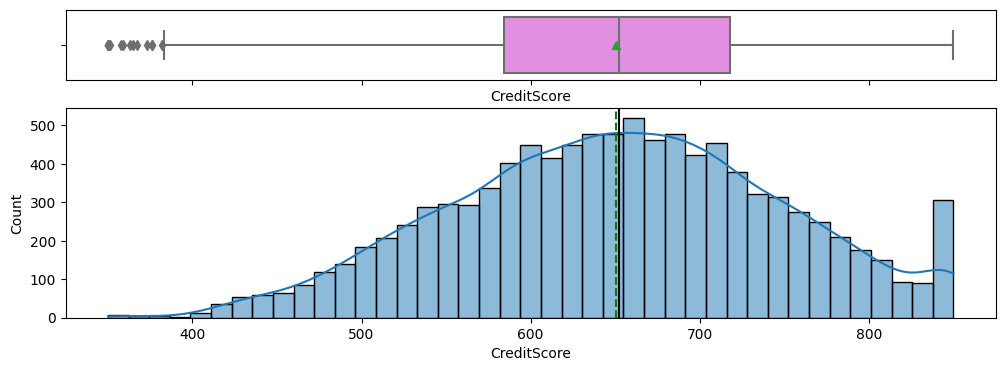

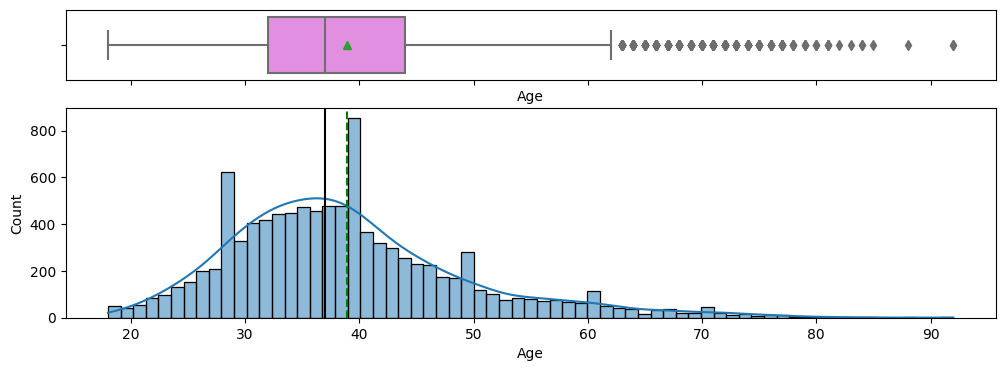

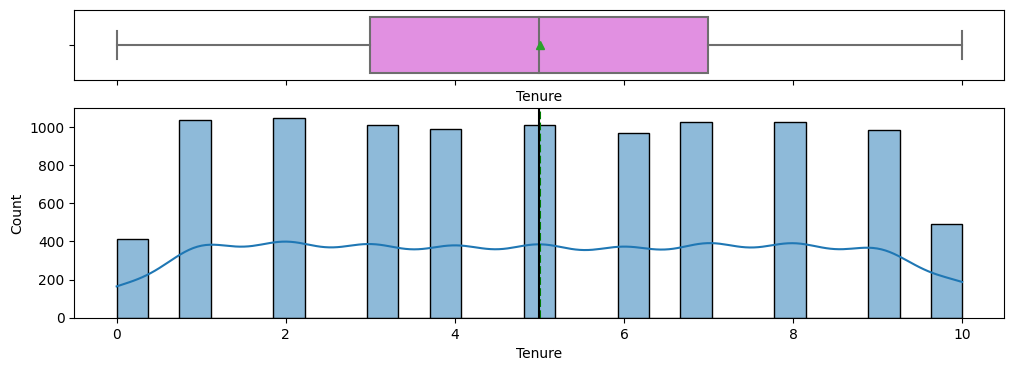

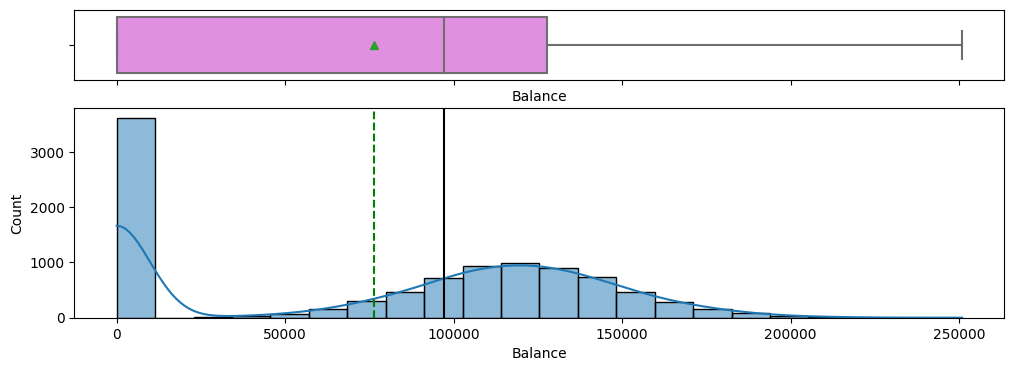

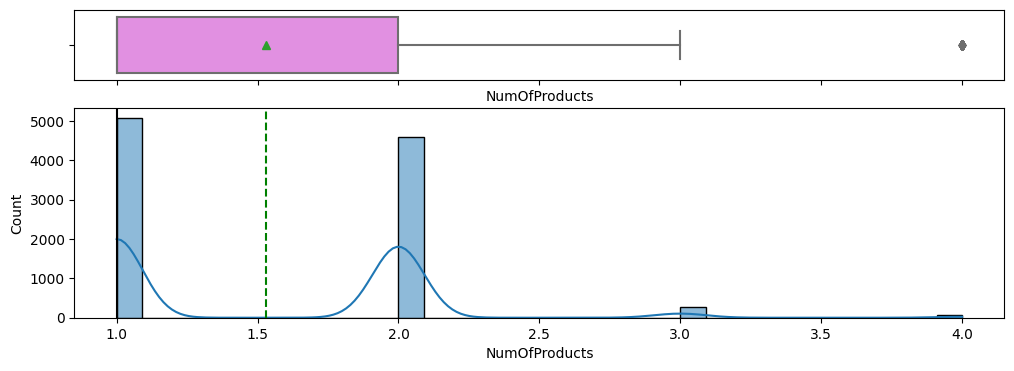

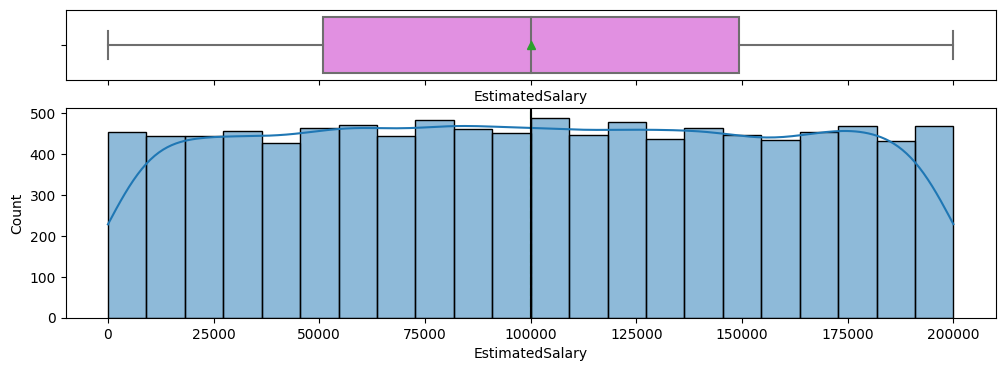

In [18]:
# selecting numerical columns
num_col = data.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    histogram_boxplot(data, item, kde=True, figsize=(12, 4))

Variables such as age, balance, and number of products are right-skewed and contain some outliers.
The credit score is left-skewed and also contains outliers.

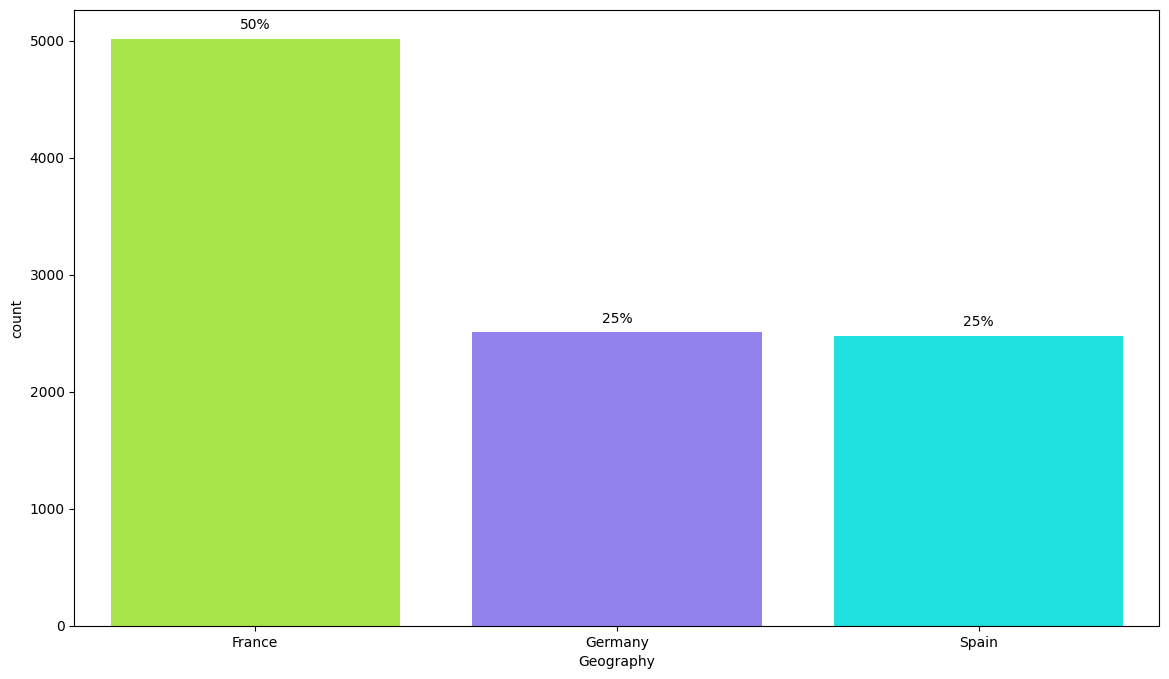

In [19]:
# Visualize categories 
plt.figure(figsize=(14,8))
total = len(data['Geography'])*1
qualitative_colors = ["#ADFF2F","#8470FF","#00FFFF","#FF1493"]
splot= sns.countplot(data=data, x='Geography', palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

Most customers are from France, while the rest is almost equally split between Germany and Spain.

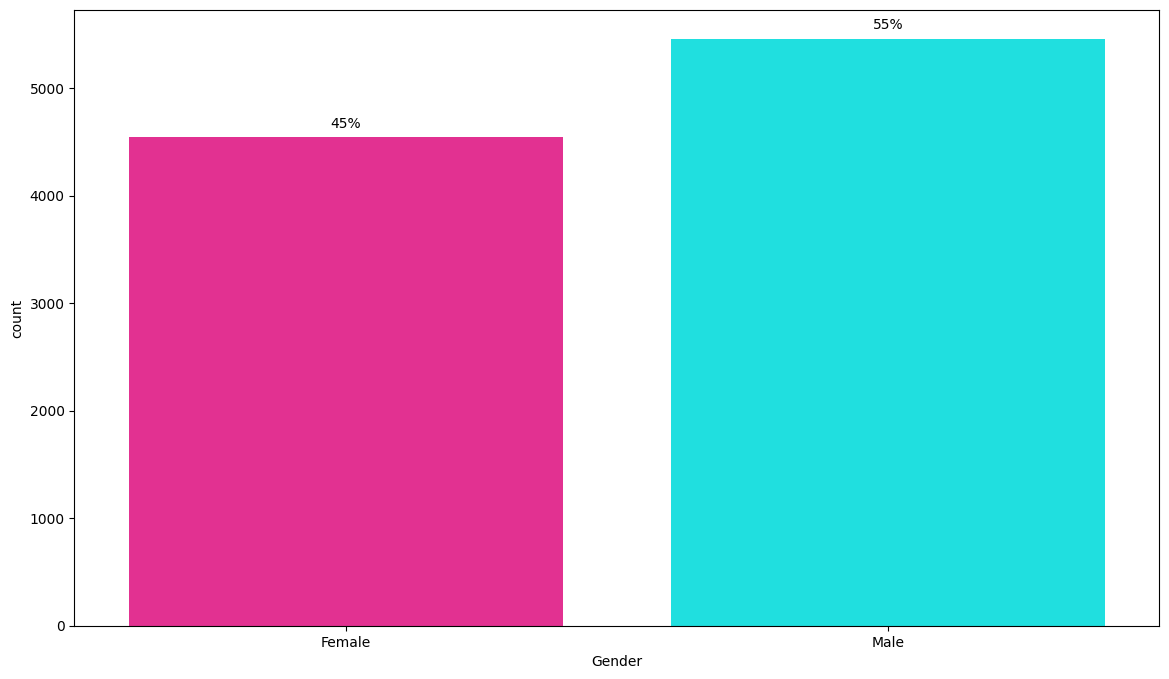

In [20]:
plt.figure(figsize=(14,8))
total = len(data['Gender'])*1
qualitative_colors = ["#FF1493","#00FFFF"]
splot= sns.countplot(data=data, x='Gender', palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

The 55% of customers are male and 45% female.

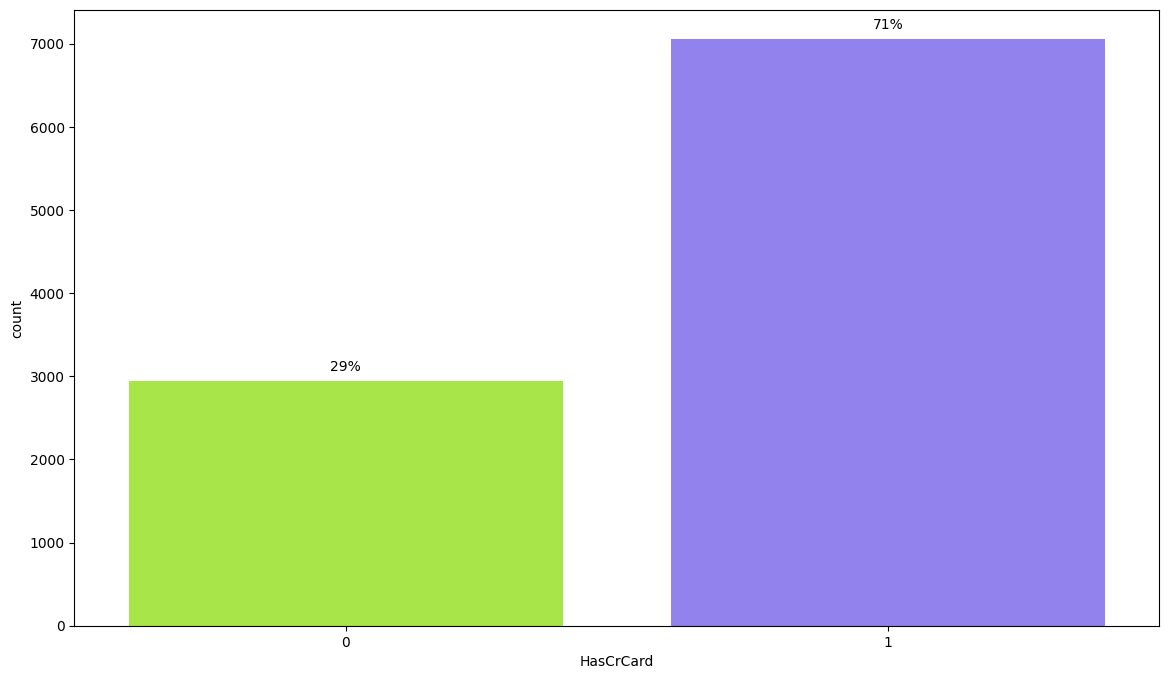

In [21]:
plt.figure(figsize=(14,8))
total = len(data['HasCrCard'])*1
qualitative_colors = ["#ADFF2F", "#8470FF"]
splot= sns.countplot(data=data, x='HasCrCard', palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

The 71% of customers have credit card while 29% not.

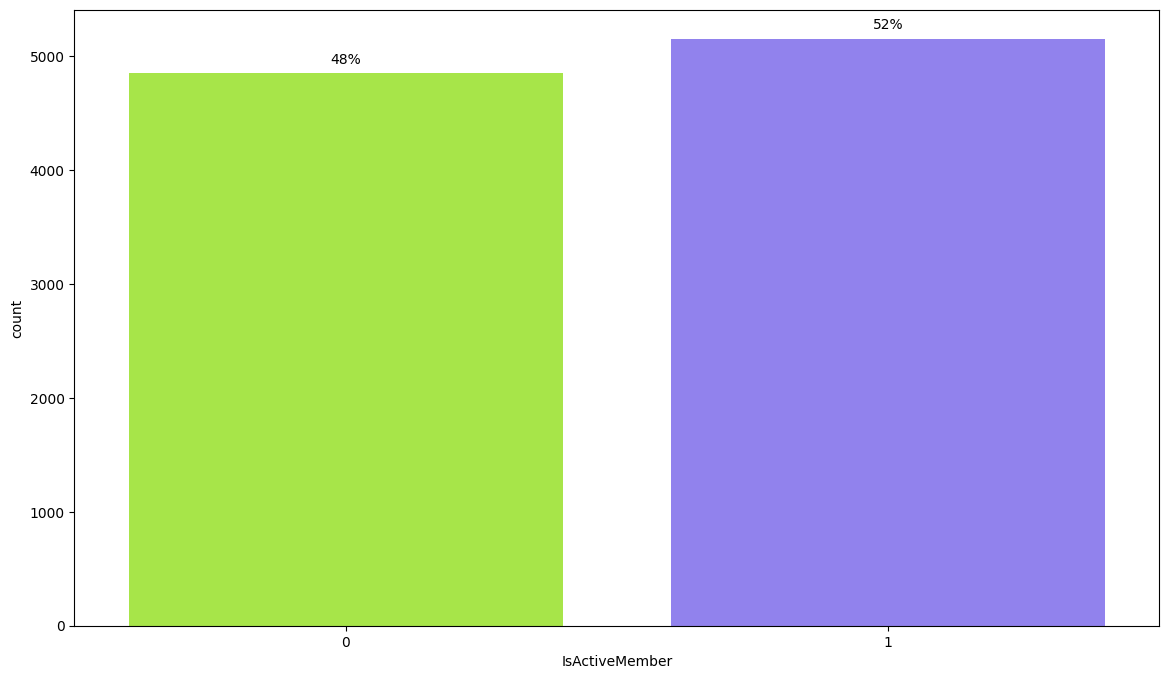

In [22]:
plt.figure(figsize=(14,8))
total = len(data['IsActiveMember'])*1
qualitative_colors = ["#ADFF2F", "#8470FF"]
splot= sns.countplot(data=data, x='IsActiveMember', palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

The 52% of customers are active members while 48% are not active.

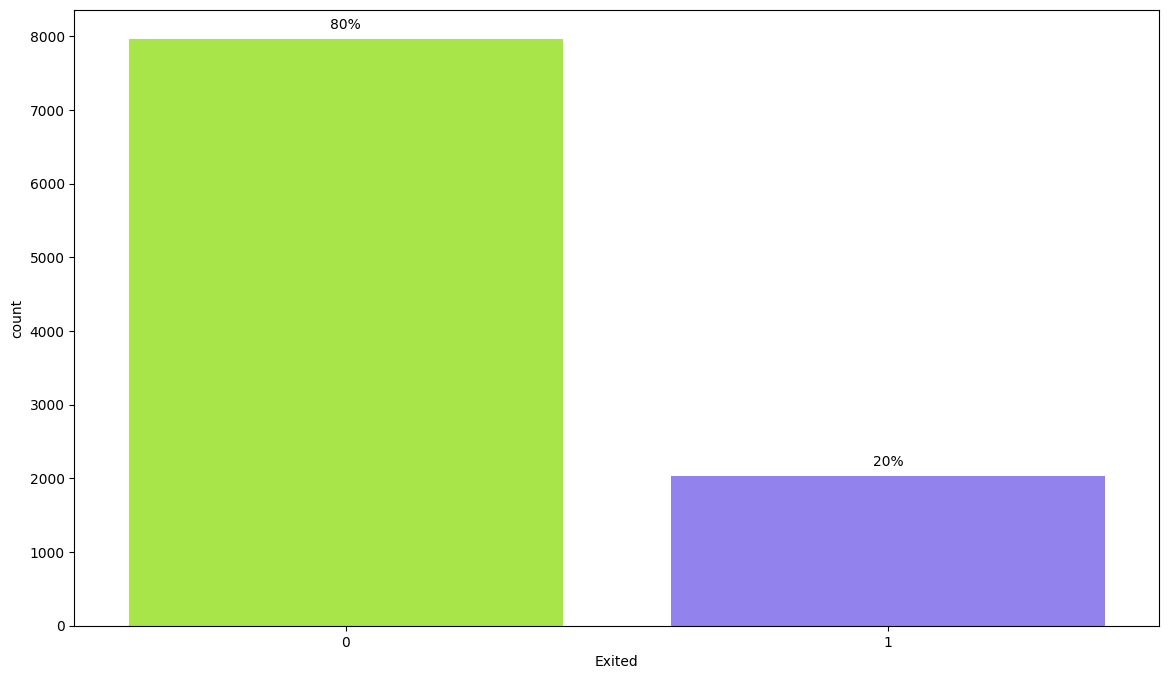

In [23]:
plt.figure(figsize=(14,8))
total = len(data['Exited'])*1
qualitative_colors = ["#ADFF2F", "#8470FF"]
splot= sns.countplot(data=data, x='Exited', palette=qualitative_colors)


for p in splot.patches:
    splot.annotate('{:.0f}%'.format(100*p.get_height()/total),
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va='center', xytext = (0,10), textcoords = 'offset points')
plt.show()

The 20% of customers exited while 80% not exited.

### Bivariate Analysis

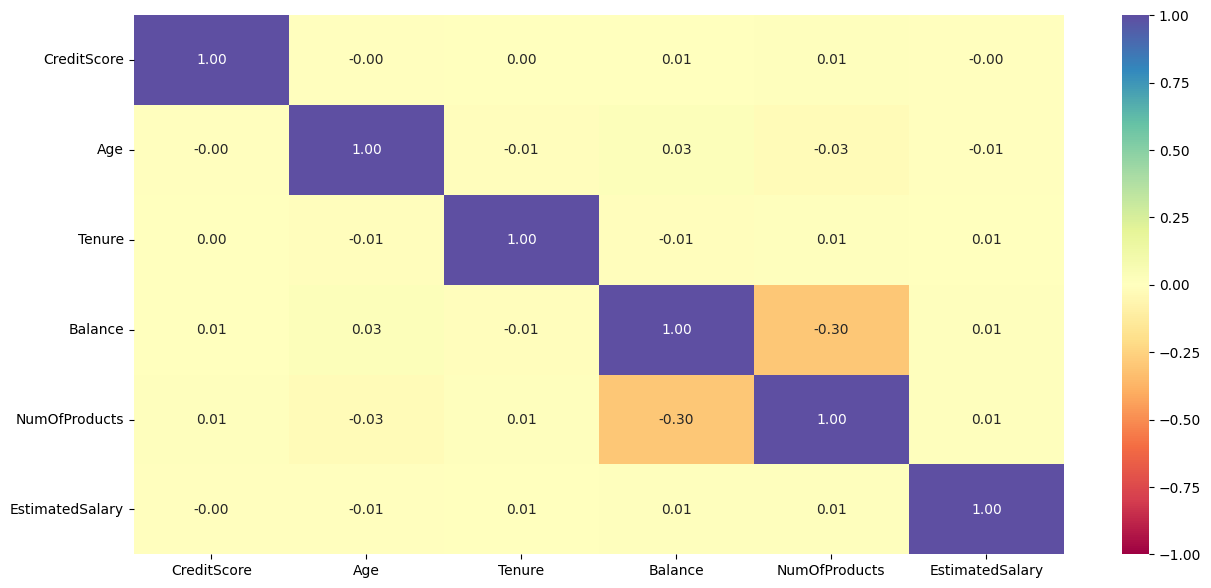

In [24]:
# Let's plot a heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(
    data[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()



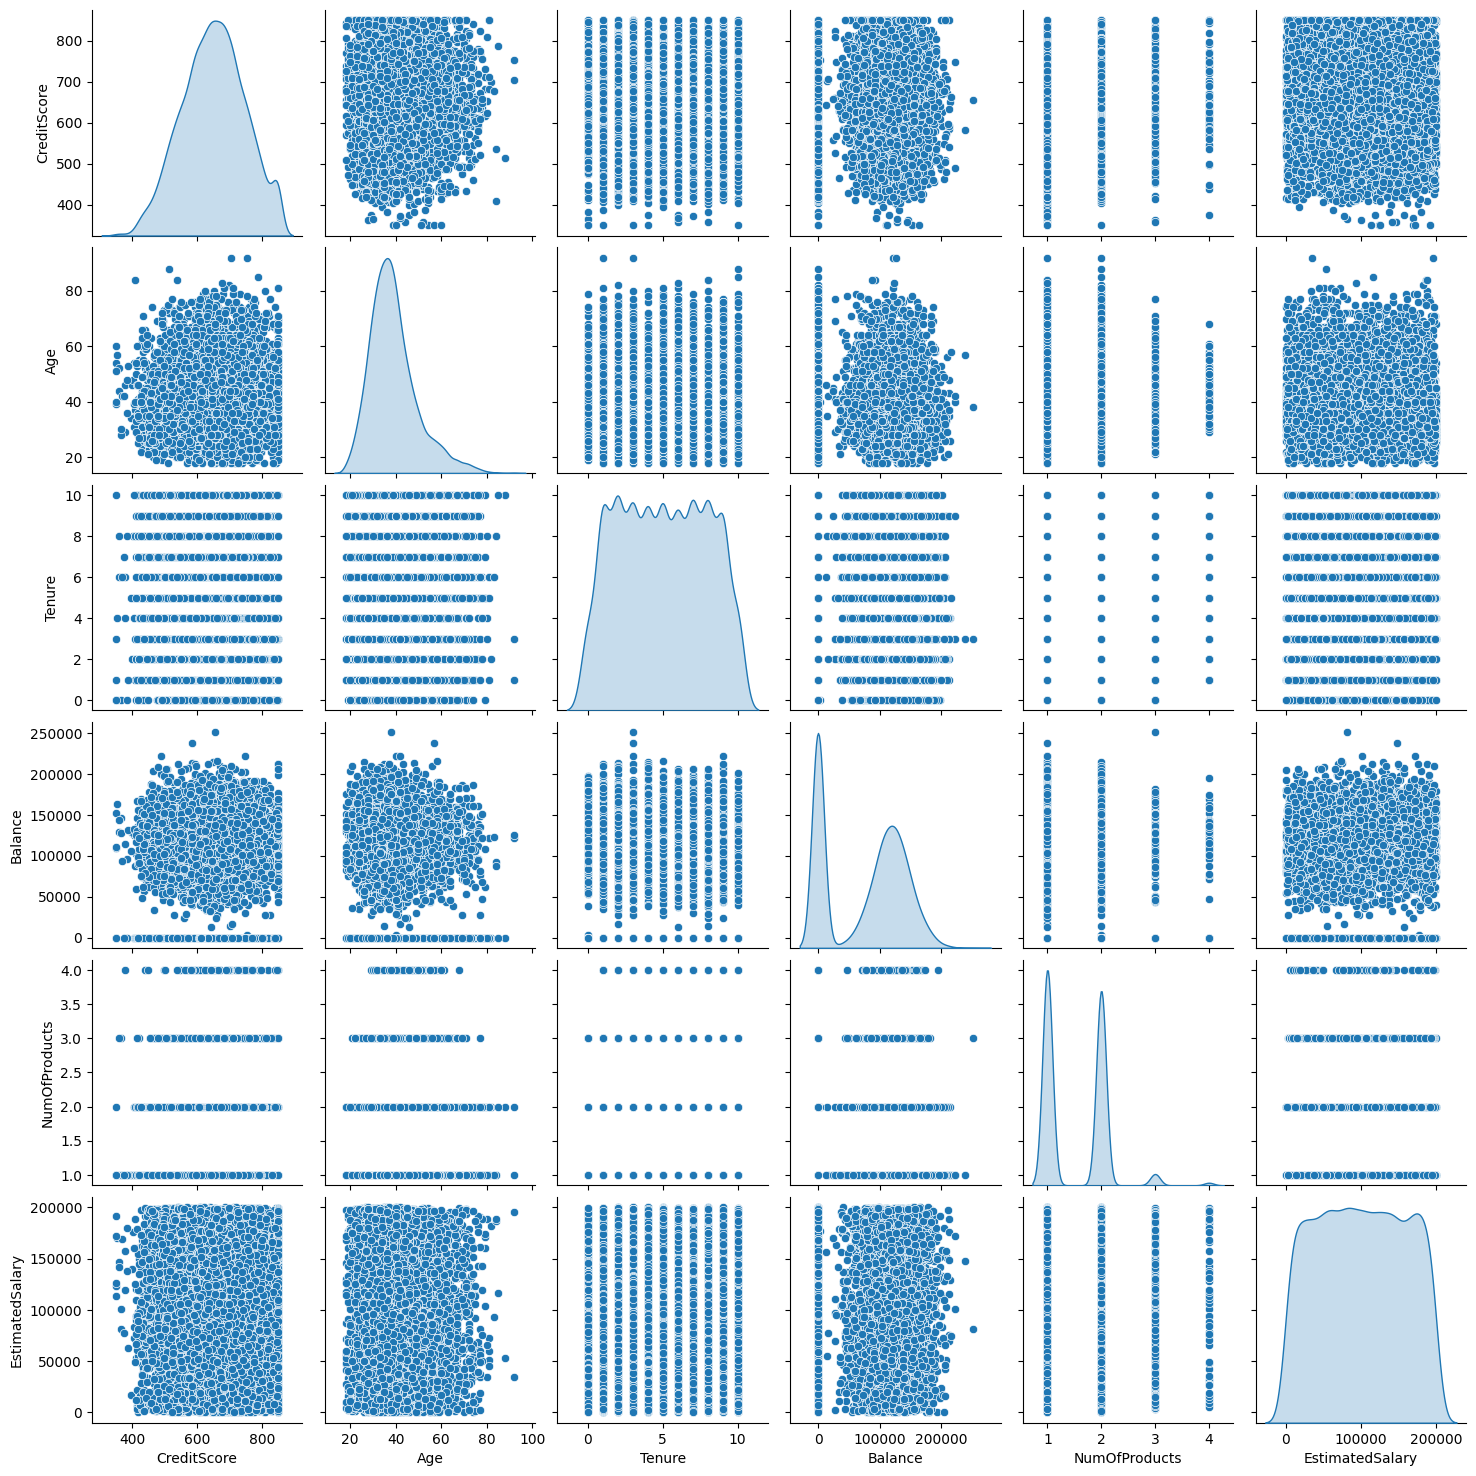

In [25]:
# Plot the pairplot
sns.pairplot(data=data[num_col], diag_kind="kde")
plt.show()

The data is not showing correlation.

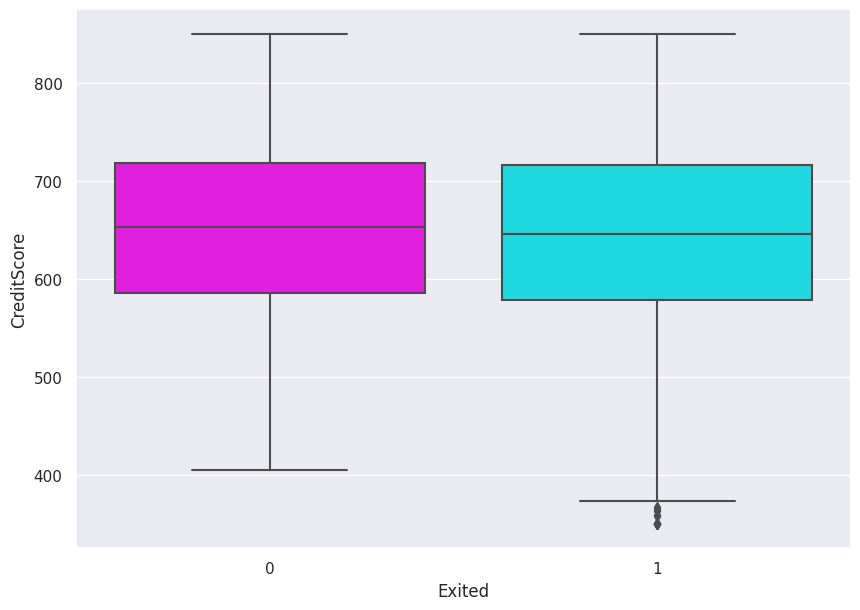

In [26]:
# Now let's review relationship between two variables
# Boxplot between exited and credit score
sns.set(rc={"figure.figsize": (10, 7)})
palette = ["#FF00FF", "#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Exited", y="CreditScore", data=data, orient="vertical")
plt.show()



Credit score is similar on both attrited customer and existing customer.
There are few outliers on the attrited customer in the lower whisker.



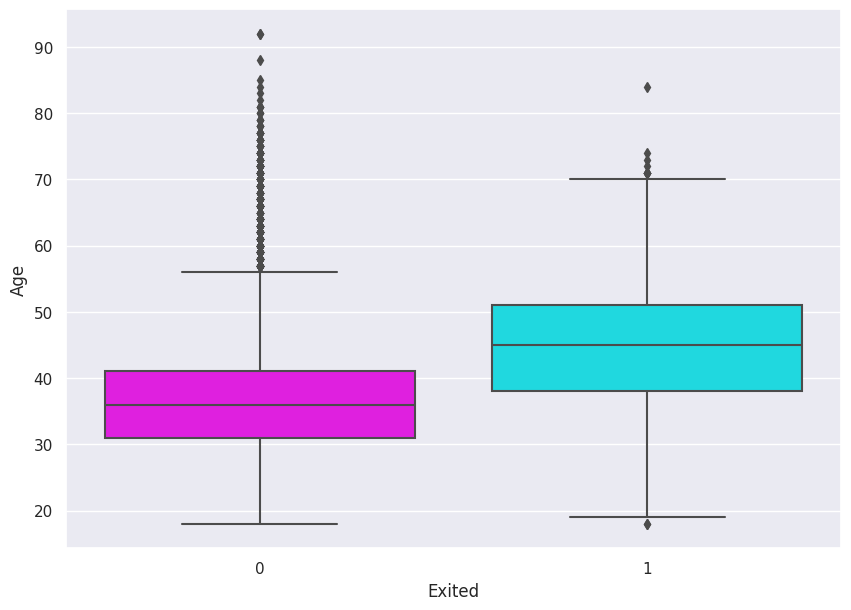

In [27]:
# Boxplot between exited and age
sns.set(rc={"figure.figsize": (10, 7)})
palette = ["#FF00FF", "#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Exited", y="Age", data=data, orient="vertical")
plt.show()

The age range of exited customer is wider than the existing customers.

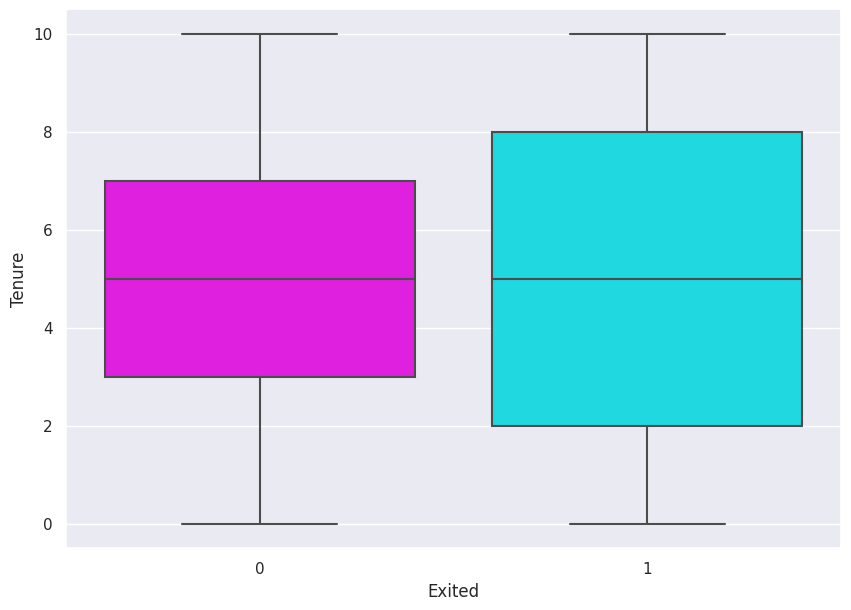

In [28]:
# Boxplot between exited and tenure
sns.set(rc={"figure.figsize": (10, 7)})
palette = ["#FF00FF", "#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Exited", y="Tenure", data=data, orient="vertical")
plt.show()



The boxplot shows a wider range of tenure on attrited customers compared with existing customers.

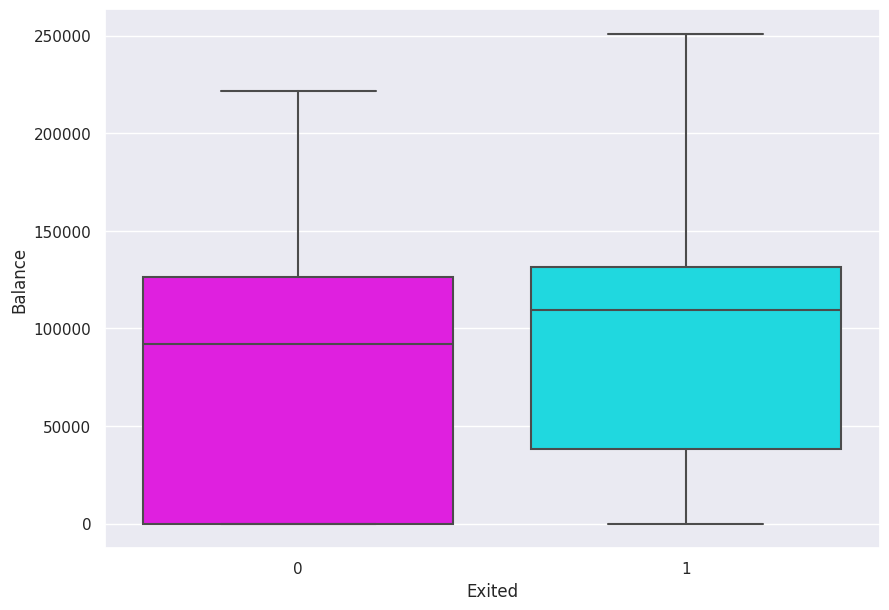

In [29]:
# Boxplot between balance and exited
sns.set(rc={"figure.figsize": (10, 7)})
palette = ["#FF00FF", "#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Exited", y="Balance", data=data, orient="vertical")
plt.show()

The boxplot shows the attrited customers have a wider range of balance amount being the majority between 46k and 140k while average balance of the existing customers is between 0 and 127k approx.

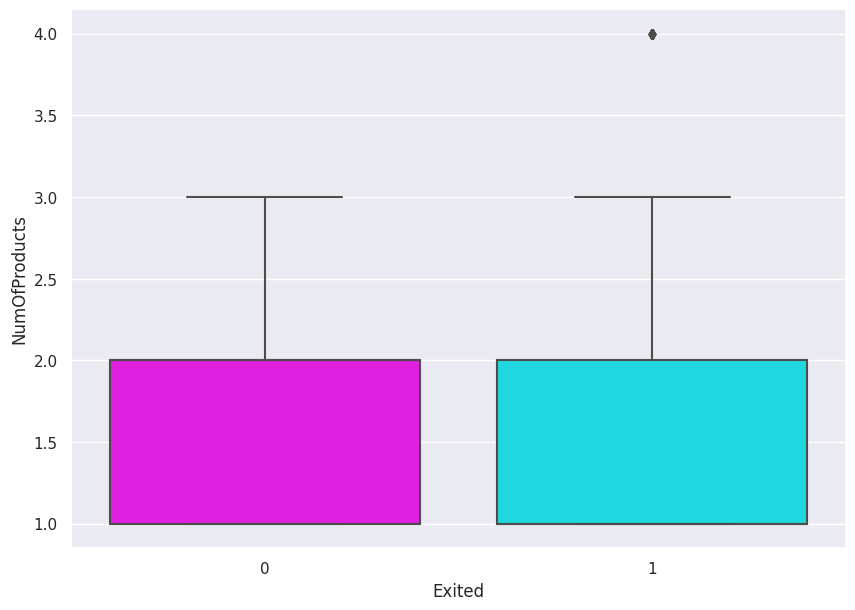

In [30]:
# Boxplot between exited and number of products
sns.set(rc={"figure.figsize": (10, 7)})
palette = ["#FF00FF", "#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Exited", y="NumOfProducts", data=data, orient="vertical")
plt.show()

The boxplot is showing no difference between exited and existing customers in relationship with the number of products.

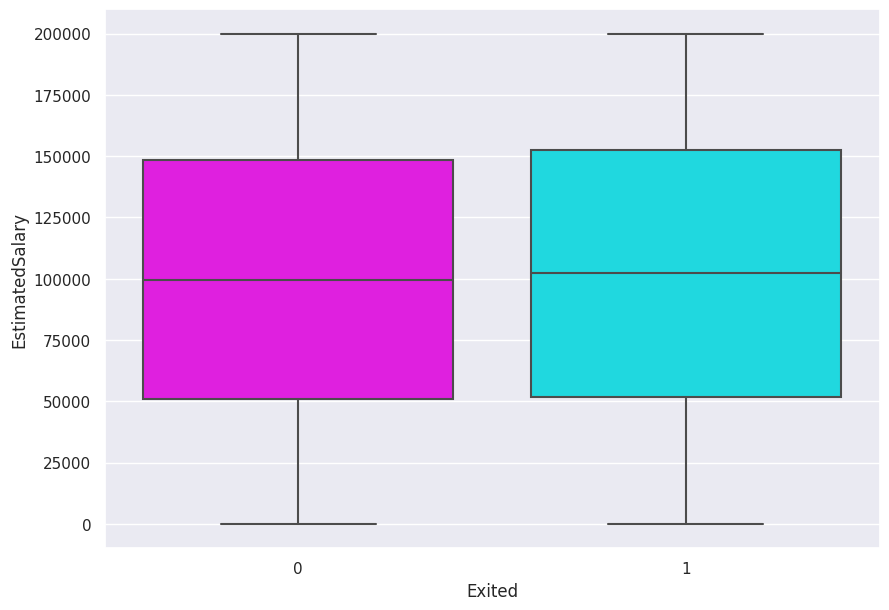

In [31]:
# Boxplot between exited and estimated salary
sns.set(rc={"figure.figsize": (10, 7)})
palette = ["#FF00FF", "#00F5FF"]
sns.set(palette=palette)
sns.boxplot(x="Exited", y="EstimatedSalary", data=data, orient="vertical")
plt.show()



The boxplot is showing no difference between exited and existing customers in relationship with the estimated salary.

In [32]:
# No to look the relationship plotting stacked bar charts
def stacked_plot(x):
    palette = ["#00FA9A", "#7B68EE"]
    sns.set(palette=palette)
    tab1 = pd.crosstab(x, data["Exited"], margins=True)
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(x, data["Exited"], normalize="index")
    tab.plot(kind="bar", stacked=True, figsize=(10, 5))

    plt.xticks(rotation=360)

    # plt.legend(loc='lower left', frameon=False)
    # plt.legend(loc="upper left", bbox_to_anchor=(0,1))
    plt.show()

Exited        0     1    All
Geography                   
France     4204   810   5014
Germany    1695   814   2509
Spain      2064   413   2477
All        7963  2037  10000
------------------------------------------------------------------------------------------------------------------------


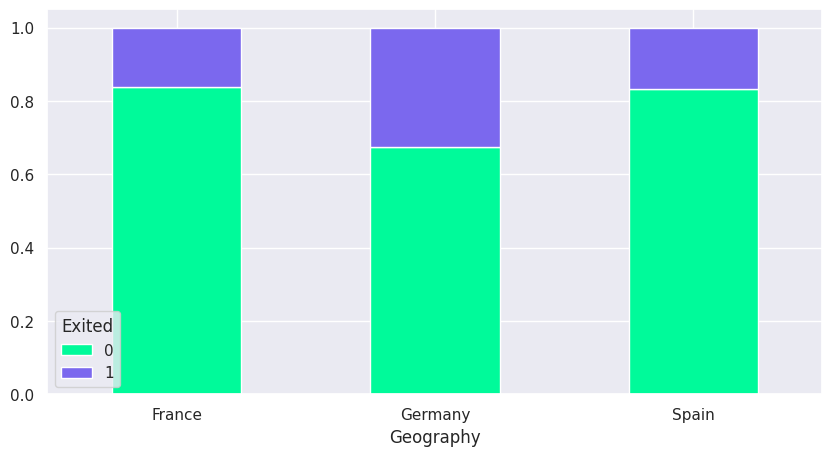

In [33]:
# Stacked plot between exited and geography
stacked_plot(data["Geography"])

The majority of customer that left the bank relates to Germany, there is no a significant difference between Spain and France.

Exited     0     1    All
Gender                   
Female  3404  1139   4543
Male    4559   898   5457
All     7963  2037  10000
------------------------------------------------------------------------------------------------------------------------


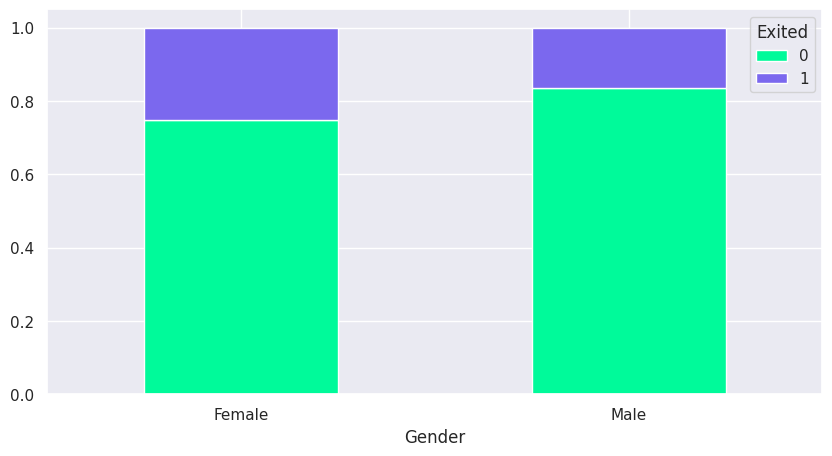

In [34]:
# Stacked plot between exited and gender
stacked_plot(data["Gender"])



The majority that left the bank correspond to female customers.

Exited        0     1    All
HasCrCard                   
0          2332   613   2945
1          5631  1424   7055
All        7963  2037  10000
------------------------------------------------------------------------------------------------------------------------


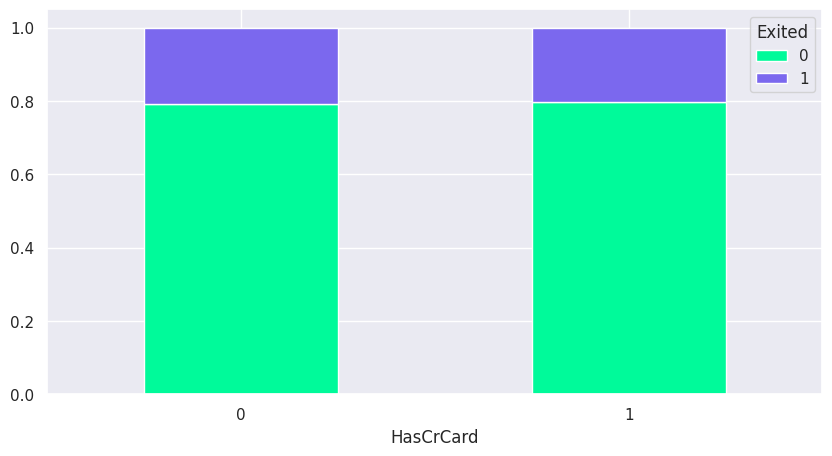

In [35]:
# Stacked plot between existed and having a credit card
stacked_plot(data["HasCrCard"])



The stacked plot is showing there is no difference about having a credit card for attrited and existing customers.

Exited             0     1    All
IsActiveMember                   
0               3547  1302   4849
1               4416   735   5151
All             7963  2037  10000
------------------------------------------------------------------------------------------------------------------------


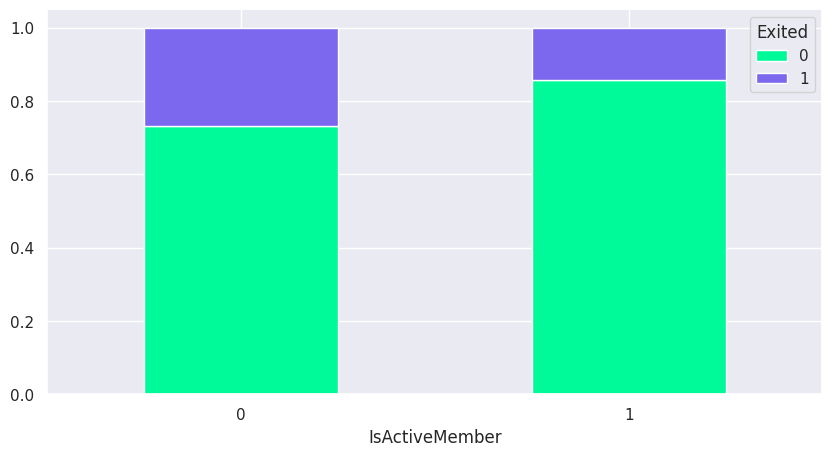

In [36]:
# Stacked plot between exited and active members
stacked_plot(data["IsActiveMember"])

The stacked plot is showing there were more no active members leaving the bank.

### Additional Data Preparation

In [37]:
# Check the first lines
data.head()



,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
# Let's replace categorical variables into dummies
oneHotCols = ["Geography", "Gender"]

In [39]:
data = pd.get_dummies(data, columns=oneHotCols)
data.head(10)



,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False
5,645,44,8,113755.78,2,1,0,149756.71,1,False,False,True,False,True
6,822,50,7,0.00,2,1,1,10062.80,0,True,False,False,False,True
7,376,29,4,115046.74,4,1,0,119346.88,1,False,True,False,True,False
8,501,44,4,142051.07,2,0,1,74940.50,0,True,False,False,False,True
9,684,27,2,134603.88,1,1,1,71725.73,0,True,False,False,False,True


#### Split the target variable and predictors

In [40]:
# Making variables into Categorical Types
cat_vars = ["HasCrCard", "IsActiveMember", "Exited"]
for colname in cat_vars:
    data[colname] = data[colname].astype("int64")

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_France   10000 non-null  bool   
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bool   
 12  Gender_Female      10000 non-null  bool   
 13  Gender_Male        10000 non-null  bool   
dtypes: bool(5), float64(2), int64(7)
memory usage: 752.1 KB


In [41]:
X_data = data.drop(["Exited"], axis=1)
y_data = data["Exited"]

In [42]:
# splitting in training and test set
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.3, random_state=42
)

In [43]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [44]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7000, 13)
(3000, 13)
(7000,)
(3000,)



## Model Evaluation Criterion
#### Model can make wrong prediction as:

    Predicting a client will leave the bank and the client doesn't leave.
    Predicting a client will not leave the bank and the client leaves.

#### Which case is more important?

Predicting that a client will not leave the bank but he/she does. Based on the focus should be on increasing Recall or minimizing the false negatives or in other words identifying the true positives.


### Model Building

In [45]:
def make_confusion_matrix(
    cf,
    group_names=None,
    categories="auto",
    count=True,
    percent=True,
    cbar=True,
    xyticks=True,
    xyplotlabels=True,
    sum_stats=True,
    figsize=None,
    cmap="Blues",
    title=None,
):
    """
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    """

    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ["" for i in range(cf.size)]

    if group_names and len(group_names) == cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = [
            "{0:.2%}".format(value) for value in cf.flatten() / np.sum(cf)
        ]
    else:
        group_percentages = blanks

    box_labels = [
        f"{v1}{v2}{v3}".strip()
        for v1, v2, v3 in zip(group_labels, group_counts, group_percentages)
    ]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0], cf.shape[1])

    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        # Accuracy is sum of diagonal divided by total observations
        accuracy = np.trace(cf) / float(np.sum(cf))

        # if it is a binary confusion matrix, show some more stats
        if len(cf) == 2:
            # Metrics for Binary Confusion Matrices
            precision = cf[1, 1] / sum(cf[:, 1])
            recall = cf[1, 1] / sum(cf[1, :])
            f1_score = 2 * precision * recall / (precision + recall)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}".format(
                accuracy, precision, recall, f1_score
            )
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""

    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize == None:
        # Get default figure size if not set
        figsize = plt.rcParams.get("figure.figsize")

    if xyticks == False:
        # Do not show categories if xyticks is False
        categories = False

    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(
        cf,
        annot=box_labels,
        fmt="",
        cmap=cmap,
        cbar=cbar,
        xticklabels=categories,
        yticklabels=categories,
    )

    if xyplotlabels:
        plt.ylabel("True label")
        plt.xlabel("Predicted label" + stats_text)
    else:
        plt.xlabel(stats_text)

    if title:
        plt.title(title)

### Random Forest

In [46]:
# Model building using random forest
from sklearn.ensemble import RandomForestClassifier

In [47]:
random_forest = RandomForestClassifier(random_state=1)

In [48]:
# Pandas Series.ravel() function returns the flattened underlying data as an ndarray.
random_forest.fit(
    X_train, y_train.values.ravel()
)  # np.ravel() Return a contiguous flattened array

RandomForestClassifier(random_state=1)

In [49]:
y_pred = random_forest.predict(X_test)

In [50]:
random_forest.score(X_test, y_test)

0.8696666666666667

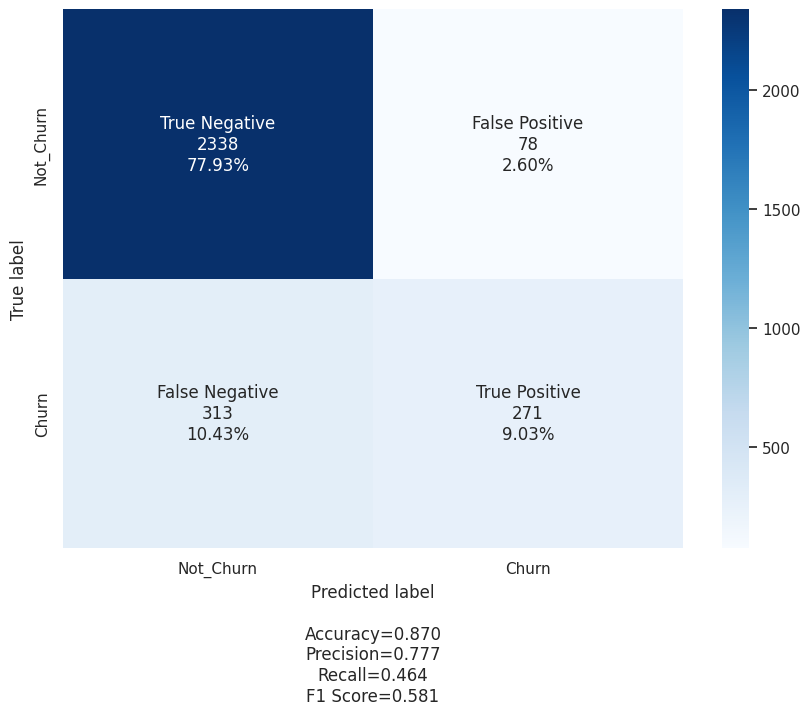

In [51]:
## Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
categories = ["Not_Churn", "Churn"]
make_confusion_matrix(cm, group_names=labels, categories=categories, cmap="Blues")



Good accuracy but pretty low recall, now let's try to check the optimal threshold AUC-ROC.

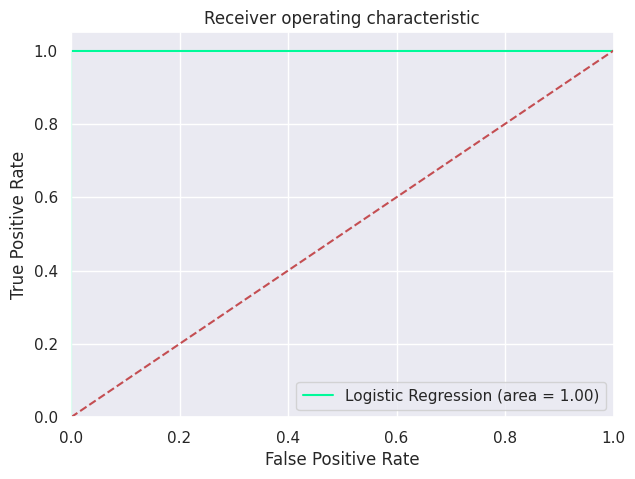

In [52]:
# Plotting the AUC-ROC curve
logit_roc_auc_train = roc_auc_score(y_train, random_forest.predict_proba(X_train)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, random_forest.predict_proba(X_train)[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [53]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = metrics.roc_curve(y_test, random_forest.predict_proba(X_test)[:,1])

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

0.27


In [54]:
optimal_threshold = 0.27

# Model prediction with optimal threshold
pred_train_opt = random_forest.predict_proba(X_train)[:, 1] > optimal_threshold
pred_test_opt = random_forest.predict_proba(X_test)[:, 1] > optimal_threshold

# Model performance with optimal threhold

print("Accuracy on train data:", accuracy_score(y_train, pred_train_opt))
print("Accuracy on test data:", accuracy_score(y_test, pred_test_opt))

print("Recall on train data:", recall_score(y_train, pred_train_opt))
print("Recall on test data:", recall_score(y_test, pred_test_opt))

print("Precision on train data:", precision_score(y_train, pred_train_opt))
print("Precision on test data:", precision_score(y_test, pred_test_opt))

print("ROC-AUC Score on train data:", roc_auc_score(y_train, pred_train_opt))
print("ROC-AUC Score on test data:", roc_auc_score(y_test, pred_test_opt))

Accuracy on train data: 0.9911428571428571
Accuracy on test data: 0.8086666666666666
Recall on train data: 1.0
Recall on test data: 0.690068493150685
Precision on train data: 0.9590759075907591
Precision on test data: 0.5062814070351759
ROC-AUC Score on train data: 0.994411393546061
ROC-AUC Score on test data: 0.7637014651183888


Recall has improved compared with previous model but there is overfitting.

### Random Forest Classifier

In [55]:
# Choose the type of classifier.
rf_estimator_tuned = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    "n_estimators": [150, 200, 250],
    "min_samples_leaf": np.arange(7, 10),
    "max_features": np.arange(0.2, 0.7, 0.1),
    "max_samples": np.arange(0.3, 0.7, 0.1),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = RandomizedSearchCV(rf_estimator_tuned, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_estimator_tuned.fit(X_train, y_train)

RandomForestClassifier(max_features=0.6000000000000001, max_samples=0.5,
                       min_samples_leaf=7, n_estimators=150, random_state=1)

In [56]:
y_pred = rf_estimator_tuned.predict(X_test)

In [57]:
rf_estimator_tuned.score(X_test, y_test)



0.8696666666666667

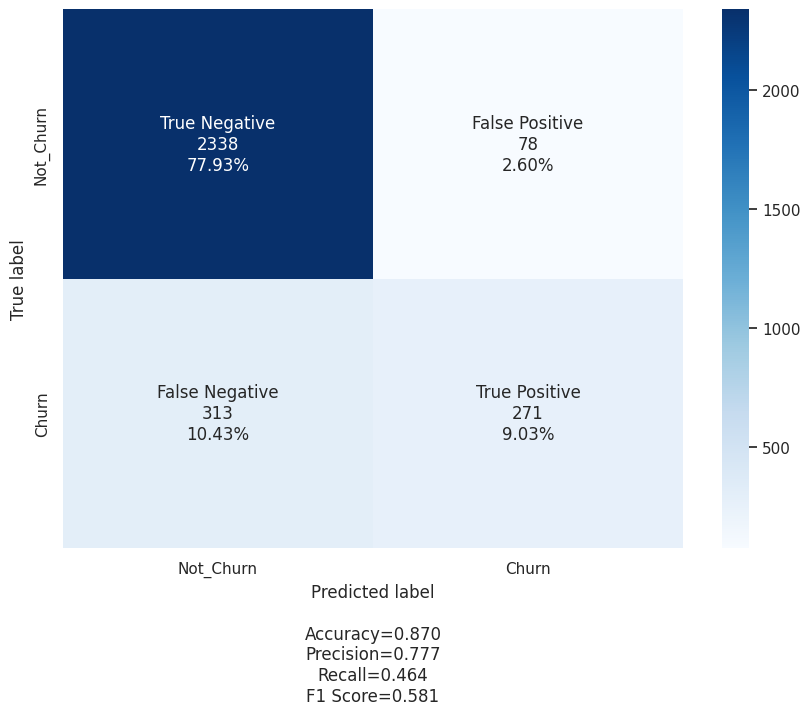

In [58]:
## Confusion Matrix
cm3 = confusion_matrix(y_test, y_pred)
labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
categories = ["Not_Churn", "Churn"]
make_confusion_matrix(cm3, group_names=labels, categories=categories, cmap="Blues")



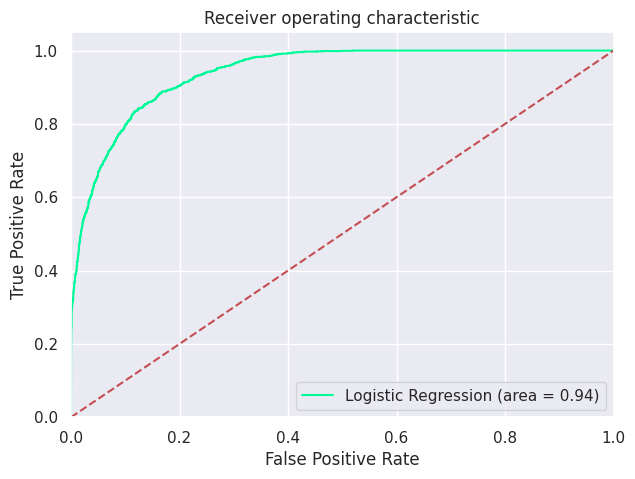

In [59]:
# Plotting the ROC-AUC curve
logit_roc_auc_train = roc_auc_score(
    y_train, rf_estimator_tuned.predict_proba(X_train)[:, 1]
)
fpr, tpr, thresholds = roc_curve(
    y_train, rf_estimator_tuned.predict_proba(X_train)[:, 1]
)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [60]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = metrics.roc_curve(y_test, rf_estimator_tuned.predict_proba(X_test)[:,1])

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

0.2196921724073427


In [61]:
optimal_threshold = 0.24

# Model prediction with optimal threshold
pred_train_opt = rf_estimator_tuned.predict_proba(X_train)[:, 1] > optimal_threshold
pred_test_opt = rf_estimator_tuned.predict_proba(X_test)[:, 1] > optimal_threshold

# Model performance with optimal threhold

print("Accuracy on train data:", accuracy_score(y_train, pred_train_opt))
print("Accuracy on test data:", accuracy_score(y_test, pred_test_opt))

print("Recall on train data:", recall_score(y_train, pred_train_opt))
print("Recall on test data:", recall_score(y_test, pred_test_opt))

print("Precision on train data:", precision_score(y_train, pred_train_opt))
print("Precision on test data:", precision_score(y_test, pred_test_opt))

print("ROC-AUC Score on train data:", roc_auc_score(y_train, pred_train_opt))
print("ROC-AUC Score on test data:", roc_auc_score(y_test, pred_test_opt))

Accuracy on train data: 0.8584285714285714
Accuracy on test data: 0.8143333333333334
Recall on train data: 0.856159669649002
Recall on test data: 0.7431506849315068
Precision on train data: 0.6140177690029615
Precision on test data: 0.5160523186682521
ROC-AUC Score on train data: 0.8575912824538503
ROC-AUC Score on test data: 0.7873452100154223


Recall is much better with the optimal threshold and compared also with the previous model.

### Random forest class_weights for random forest

The model performance is not good. There is class imbalance with 80% non-exited customers and 20% exited customers.
Let's fix the model making the class interest


In [62]:
# Choose the type of classifier.
rf_estimator_weighted = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    "class_weight": [{0: 0.2, 1: 0.8}],
    "n_estimators": [100, 150, 200, 250],
    "min_samples_leaf": np.arange(5, 10),
    "max_features": np.arange(0.2, 0.7, 0.1),
    "max_samples": np.arange(0.3, 0.7, 0.1),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = RandomizedSearchCV(
    rf_estimator_weighted, parameters, scoring=acc_scorer, cv=5
)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator_weighted = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_estimator_weighted.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.2, 1: 0.8},
                       max_features=0.5000000000000001,
                       max_samples=0.6000000000000001, min_samples_leaf=9,
                       n_estimators=200, random_state=1)

In [63]:
y_pred = rf_estimator_weighted.predict(X_test)

In [64]:
rf_estimator_weighted.score(X_test, y_test)

0.842

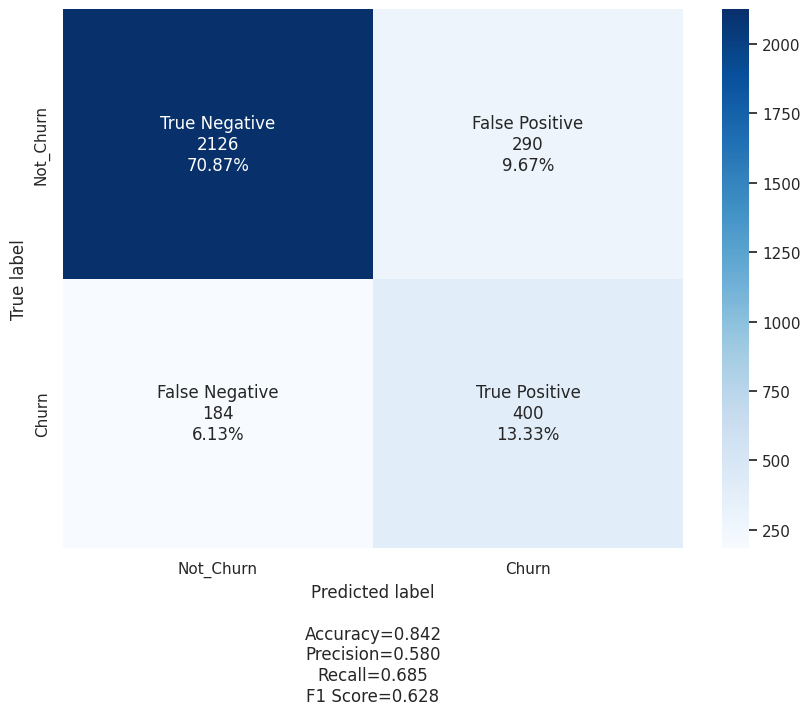

In [65]:
cm4 = confusion_matrix(y_test, y_pred)
labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
categories = ["Not_Churn", "Churn"]
make_confusion_matrix(cm4, group_names=labels, categories=categories, cmap="Blues")

The random forest class_weights metrics are much better than the previous models, recall is still low.

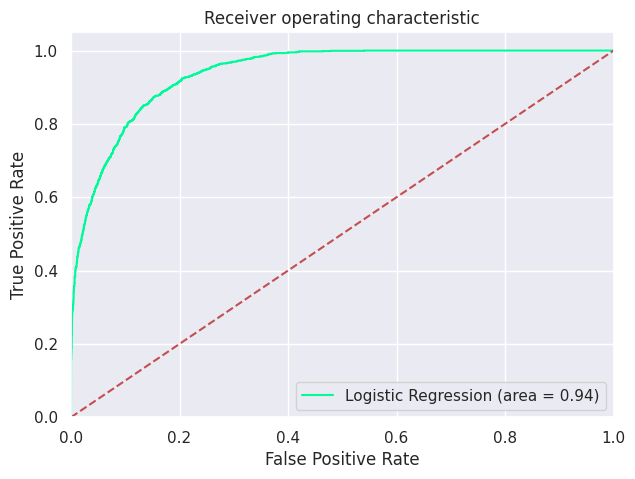

In [66]:
# Plotting the ROC-AUC curve
logit_roc_auc_train = roc_auc_score(
    y_train, rf_estimator_weighted.predict_proba(X_train)[:, 1]
)
fpr, tpr, thresholds = roc_curve(
    y_train, rf_estimator_weighted.predict_proba(X_train)[:, 1]
)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [67]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = metrics.roc_curve(y_test, rf_estimator_weighted.predict_proba(X_test)[:,1])

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

0.4423234994962442


In [68]:
optimal_threshold = 0.42

# Model prediction with optimal threshold
pred_train_opt = rf_estimator_weighted.predict_proba(X_train)[:, 1] > optimal_threshold
pred_test_opt = rf_estimator_weighted.predict_proba(X_test)[:, 1] > optimal_threshold

# Model performance with optimal threhold

print("Accuracy on train data:", accuracy_score(y_train, pred_train_opt))
print("Accuracy on test data:", accuracy_score(y_test, pred_test_opt))

print("Recall on train data:", recall_score(y_train, pred_train_opt))
print("Recall on test data:", recall_score(y_test, pred_test_opt))

print("Precision on train data:", precision_score(y_train, pred_train_opt))
print("Precision on test data:", precision_score(y_test, pred_test_opt))

print("ROC-AUC Score on train data:", roc_auc_score(y_train, pred_train_opt))
print("ROC-AUC Score on test data:", roc_auc_score(y_test, pred_test_opt))

Accuracy on train data: 0.8487142857142858
Accuracy on test data: 0.8073333333333333
Recall on train data: 0.8768066070199587
Recall on test data: 0.7551369863013698
Precision on train data: 0.5914577530176416
Precision on test data: 0.5034246575342466
ROC-AUC Score on train data: 0.8590811473895538
ROC-AUC Score on test data: 0.7875436587135988


Better metrics since there is less overfitting, let's try with logistic regression.

### Logistic Regression

In [69]:
logistic_regression = LogisticRegression(random_state=1)
lg = logistic_regression.fit(X_train, y_train)

In [70]:
y_pred = logistic_regression.predict(X_test)

In [71]:
logistic_regression.score(X_test, y_test)

0.8113333333333334

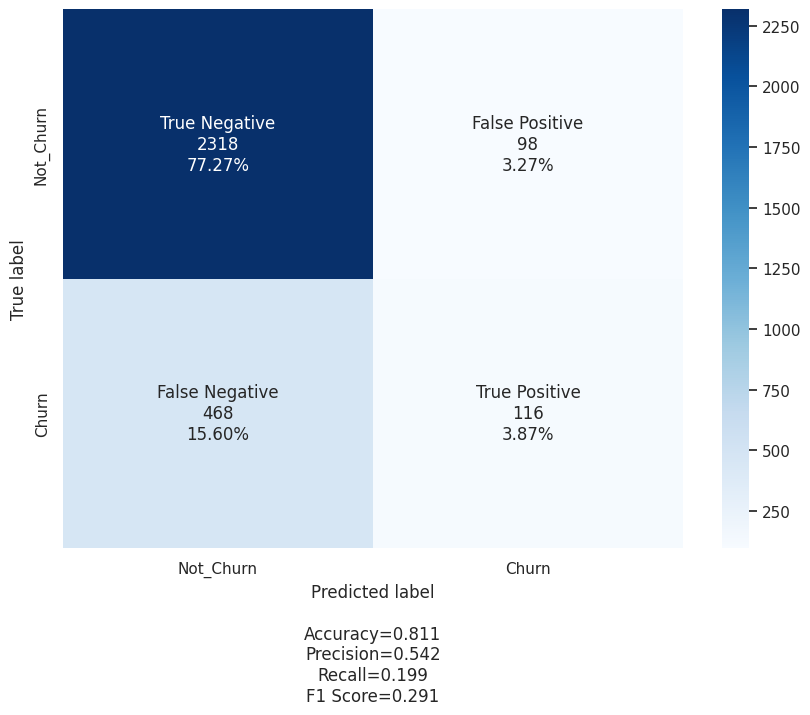

In [72]:
cm1 = confusion_matrix(y_test, y_pred)
labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
categories = ["Not_Churn", "Churn"]
make_confusion_matrix(cm1, group_names=labels, categories=categories, cmap="Blues")

Pretty low recall now let's try find the optimal AUC-ROC.

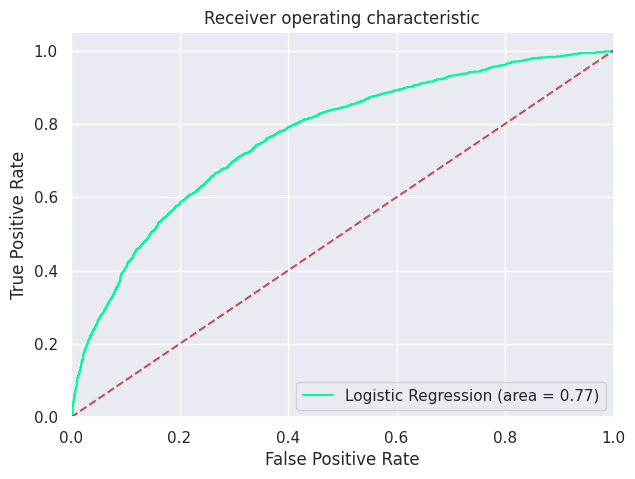

In [73]:
# Calculate the AUC-ROC curve
logit_roc_auc_train = roc_auc_score(
    y_train, logistic_regression.predict_proba(X_train)[:, 1]
)
fpr, tpr, thresholds = roc_curve(
    y_train, logistic_regression.predict_proba(X_train)[:, 1]
)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [74]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = metrics.roc_curve(y_test, logistic_regression.predict_proba(X_test)[:,1])

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)



0.23136983825466229


In [75]:
optimal_threshold = 0.23

# Model prediction with optimal threshold
pred_train_opt = logistic_regression.predict_proba(X_train)[:, 1] > optimal_threshold
pred_test_opt = logistic_regression.predict_proba(X_test)[:, 1] > optimal_threshold

# Model performance with optimal threhold

print("Accuracy on train data:", accuracy_score(y_train, pred_train_opt))
print("Accuracy on test data:", accuracy_score(y_test, pred_test_opt))

print("Recall on train data:", recall_score(y_train, pred_train_opt))
print("Recall on test data:", recall_score(y_test, pred_test_opt))

print("Precision on train data:", precision_score(y_train, pred_train_opt))
print("Precision on test data:", precision_score(y_test, pred_test_opt))

print("ROC-AUC Score on train data:", roc_auc_score(y_train, pred_train_opt))
print("ROC-AUC Score on test data:", roc_auc_score(y_test, pred_test_opt))

Accuracy on train data: 0.728
Accuracy on test data: 0.731
Recall on train data: 0.6400550584996559
Recall on test data: 0.6626712328767124
Precision on train data: 0.4024231934227607
Precision on test data: 0.3881644934804413
ROC-AUC Score on train data: 0.695545827429024
ROC-AUC Score on test data: 0.7050938945840516


### Model Building - Neural Networks

In [76]:
# Initializing the ANN
model = Sequential()

In [77]:
# This adds the input layer (by specifying input dimension) AND the first hidden layer (units)
model.add(
    Dense(units=13, input_dim=13, activation="relu")
)  # input of 13 columns as shown above
# hidden layer
model.add(Dense(units=24, activation="relu"))
# Adding Dropout to prevent overfitting
model.add(Dense(24, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(24, activation="relu"))
# Adding the output layer
# We use the sigmoid because we want probability outcomes
model.add(Dense(1, activation="sigmoid"))  # binary classification fraudulent or not

In [78]:
# Create optimizer with default learning rate
# Compile the model
model.compile(optimizer='SGD', loss='mse', metrics=['accuracy'])

In [79]:
# fitting the model
history = model.fit(X_train, y_train, batch_size=32, epochs=100, validation_split=0.2)

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5515 - loss: 0.2452 - val_accuracy: 0.7943 - val_loss: 0.1976
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7916 - loss: 0.1941 - val_accuracy: 0.7943 - val_loss: 0.1738
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7885 - loss: 0.1768 - val_accuracy: 0.7943 - val_loss: 0.1648
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7874 - loss: 0.1710 - val_accuracy: 0.7943 - val_loss: 0.1611
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7906 - loss: 0.1667 - val_accuracy: 0.7943 - val_loss: 0.1593
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7951 - loss: 0.1626 - val_accuracy: 0.7943 - val_loss: 0.1580
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7912 - loss: 0.1625 - val_accuracy: 0.7943 - val_loss: 0.1570
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7880 - loss: 0.1641 - val_accu

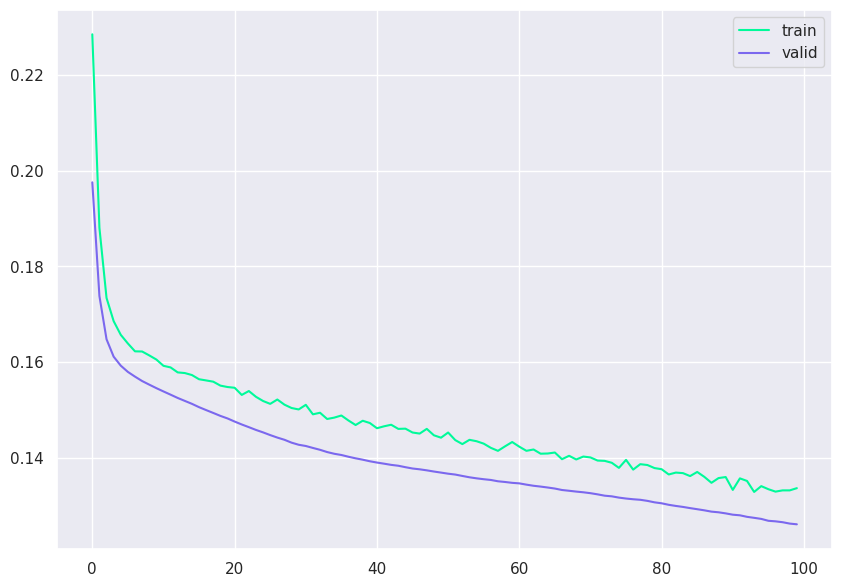

In [80]:
# Capturing learning history per epoch
hist = pd.DataFrame(history.history)
hist["epoch"] = history.epoch

# Plotting accuracy at different epochs
plt.plot(hist["loss"])
plt.plot(hist["val_loss"])
plt.legend(("train", "valid"), loc=0)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


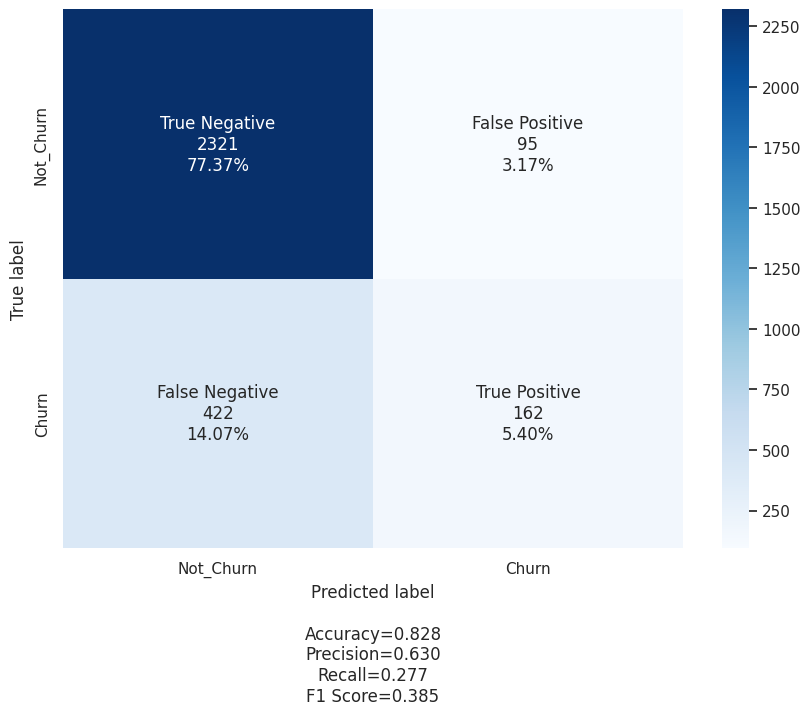

In [81]:
## Confusion Matrix on unsee test set
import seaborn as sn

y_pred1 = model.predict(X_test)
for i in range(len(y_test)):
    if y_pred1[i] > 0.5:
        y_pred1[i] = 1
    else:
        y_pred1[i] = 0


cm2 = confusion_matrix(y_test, y_pred1)
labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
categories = ["Not_Churn", "Churn"]
make_confusion_matrix(cm2, group_names=labels, categories=categories, cmap="Blues")

The above model demonstrates good accuracy but struggles with low recall. This issue could stem from the following reasons:

Imbalanced Dataset: As observed in the EDA, the dataset is imbalanced, with a higher representation of the non-exited class (0).

Inappropriate Loss Function: Currently, the model utilizes the Mean Squared Error (MSE) loss function. While effective in regression tasks, it is less suitable for classification problems, especially with imbalanced datasets, as it focuses on minimizing the mean, often biased towards the majority class.

Decision Threshold: Given the dataset's imbalance, the default decision threshold (usually 0.5) may not be optimal. Instead, metrics like ROC-AUC can help identify a better threshold to improve predictions.

To address these issues, we will:

Switch to a classification-specific loss function, such as Binary Crossentropy.
Experiment with adjusting the decision threshold using the ROC-AUC curve.
Apply SMOTE (Synthetic Minority Oversampling Technique) to balance the dataset.
Tune other hyperparameters to optimize model performance.

In [82]:
def create_model():
      #Initializing the neural network
      model1 = Sequential()
      #Adding the hidden and output layers
      model1.add(Dense(64,activation='relu',input_dim = X_train.shape[1]))
      model1.add(Dense(32,activation='relu'))
      model1.add(Dense(1, activation = 'sigmoid'))
      #Compiling the ANN with RMSprop optimizer and binary cross entropy loss function 
      optimizer = tf.keras.optimizers.Adam(0.001)
      model1.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=['accuracy'])
      return model

In [83]:
model1=create_model()
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 13)                  │             182 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24)                  │             336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              25 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,745 (6.82 KB)

 Trainable params: 1,743 (6.81 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [84]:
#Fitting the ANN with batch_size = 32 and 100 epochs 
history1 = model1.fit(X_train,y_train,batch_size=32,epochs=100,verbose=1,validation_split = 0.2)

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8148 - loss: 0.1300 - val_accuracy: 0.8336 - val_loss: 0.1257
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8195 - loss: 0.1289 - val_accuracy: 0.8329 - val_loss: 0.1255
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8106 - loss: 0.1356 - val_accuracy: 0.8343 - val_loss: 0.1252
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8217 - loss: 0.1271 - val_accuracy: 0.8343 - val_loss: 0.1249
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8084 - loss: 0.1341 - val_accuracy: 0.8364 - val_loss: 0.1247
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8210 - loss: 0.1274 - val_accuracy: 0.8371 - val_loss: 0.1243
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8165 - loss: 0.1334 - val_accuracy: 0.8386 - val_loss: 0.1241
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8173 - loss: 0.1305 - val_accu

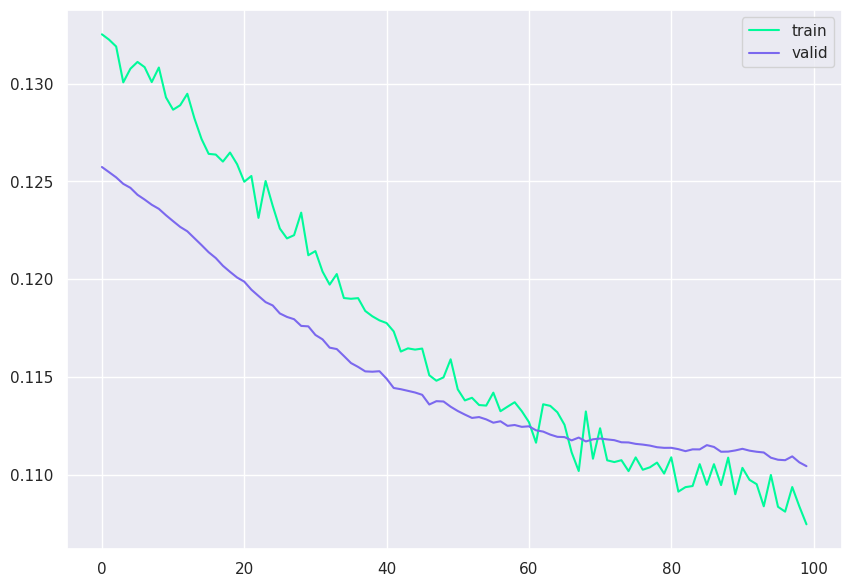

In [85]:
# Capturing learning history per epoch
hist = pd.DataFrame(history1.history)
hist["epoch"] = history1.epoch

# Plotting accuracy at different epochs
plt.plot(hist["loss"])
plt.plot(hist["val_loss"])
plt.legend(("train", "valid"), loc=0)



94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


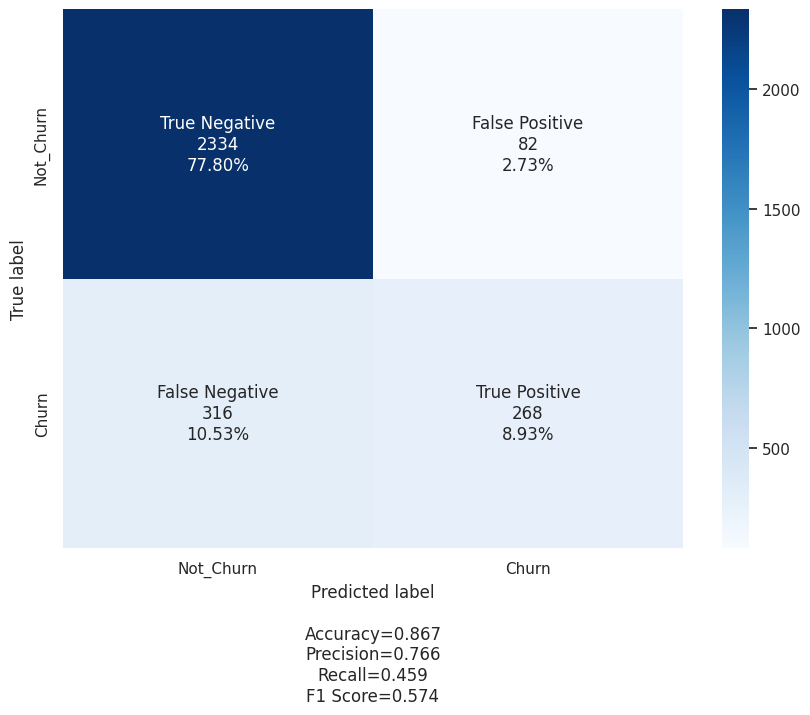

In [86]:
## Confusion Matrix on unsee test set
import seaborn as sn

y_pred1 = model1.predict(X_test)
for i in range(len(y_test)):
    if y_pred1[i] > 0.5:
        y_pred1[i] = 1
    else:
        y_pred1[i] = 0


cm2 = confusion_matrix(y_test, y_pred1)
labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
categories = ["Not_Churn", "Churn"]
make_confusion_matrix(cm2, group_names=labels, categories=categories, cmap="Blues")

In [87]:
# Calculate the AUC-ROC curve
y_pred = model1.predict(X_test).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = auc(fpr, tpr)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


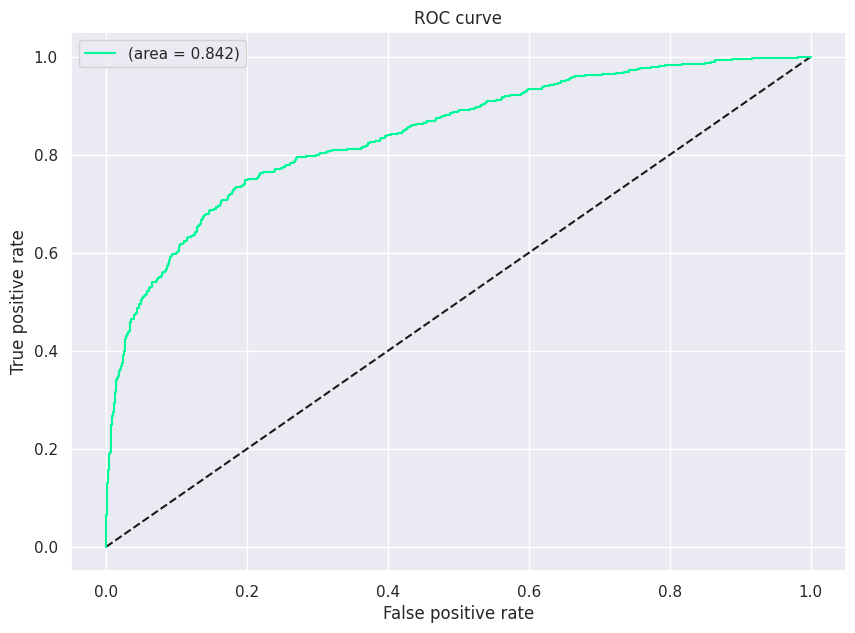

In [88]:
plt.figure(1)
plt.plot([0, 1], [0, 1], "k--")
plt.plot(fpr, tpr, label="(area = {:.3f})".format(auc))

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend(loc="best")
plt.show()